In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
a = pd.read_csv('data/charge_radii.csv')

In [3]:
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

## In this notebook we do not know yet how to add the csv radius file into selected_data.h5, so for now we are going to add it by hand

In [4]:
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

## Necessary Functions

In [5]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [6]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        # selected_models_data_sets.rename(columns={models_selected[0]: 'truth'}, inplace=True)
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets.copy() #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output_list): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)
    models_output, models_output_train, models_output_validation, models_output_test = models_output_list

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                         (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                         (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * samples[i][-2]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(sigma, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * sigma**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m
    

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage
    

In [7]:
def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, title, save_fig):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y =- filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    plt.title(f'{title}', fontsize = 25)
    plt.savefig(f'{save_fig}')
    plt.show()

In [8]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full)

In [9]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [10]:
# Extracting 2 data frames that contains predictions of different properties of nuclei
selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties)

selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, a[['N', 'Z', 'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
# This dataframe will contains all the experimental data and predictions of models for radius


truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE_df[['N', 'Z', 'BE']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True)
cols_mass = list(selected_models_data_sets_mass.keys())
# The next 2 lines help you to trainsition the truth column to the start of the dataframe
print(cols_mass)
cols_mass.remove('truth')
cols_mass.insert(2, 'truth')
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]
# This dataframe will contains all the experimental data and predictions of models for binding energies

['N', 'Z', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1', 'truth']


In [11]:
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

In [12]:
selected_models_data_sets_mass

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,127.619315,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460
1,10,8,139.807766,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181
2,12,8,151.371414,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242
3,14,8,162.027188,160.513,161.884,163.303,163.311,170.486446,167.278899,166.483309,163.855872,164.192707,157.219361
4,16,8,168.952452,167.472,168.465,170.768,170.970,178.908577,174.420231,173.303716,170.930478,171.196394,163.998623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,1909.066432,1910.765,1907.813,1909.928,1914.193,1894.445901,1900.875946,1898.639172,1902.293050,1907.479821,1908.851310
625,156,106,1923.387483,1925.019,1921.738,1924.361,1928.042,1909.221132,1915.371887,1912.434046,1916.575965,1921.884406,1922.815073
626,156,108,1926.771317,1928.415,1925.436,1927.488,1932.395,1911.680941,1918.341803,1916.133844,1919.723353,1925.454882,1926.206982
627,158,108,1941.337453,1943.010,1939.691,1942.276,1946.498,1927.231556,1933.157370,1930.669126,1934.554087,1940.259078,1940.812152


### Now we have 2 data sets separately for mass and radius, let's execute the usual analysis that we already did

In [13]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

In [14]:
filtered_NZ_df_mass = selected_models_data_sets_mass[['N', 'Z']]
filtered_NZ_mass = np.array(filtered_NZ_df_mass)
Full_set_mass = filtered_NZ_mass.copy()

### We will now want to seperate these filtered nuclei into different regions

In [15]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [16]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

In [17]:
train_coordinates_mass.shape

(300,)

In [18]:
train_coordinates_radius.shape

(167,)

In [19]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [20]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [21]:
filtered_models_output_mass_list_50 = filtered_models_output(50, models_output_mass_list)
filtered_models_output_radius_list_20 = filtered_models_output(20, models_output_radius_list)

In [22]:
filtered_models_output_mass_50 = filtered_models_output_mass_list_50[0]
filtered_models_output_mass_train_50 = filtered_models_output_mass_list_50[1]
filtered_models_output_mass_validation_50 = filtered_models_output_mass_list_50[2]
filtered_models_output_mass_test_50 = filtered_models_output_mass_list_50[3]
filtered_models_output_mass_stable_50 = filtered_models_output_mass_list_50[4]

filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_models_output_radius_train_20 = filtered_models_output_radius_list_20[1]
filtered_models_output_radius_validation_20 = filtered_models_output_radius_list_20[2]
filtered_models_output_radius_test_20 = filtered_models_output_radius_list_20[3]
filtered_models_output_radius_stable_20 = filtered_models_output_radius_list_20[4]

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

In [25]:
models_output_mass_train

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
0,8,8,16,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460,127.619315
1,10,8,18,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181,139.807766
2,12,8,20,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242,151.371414
6,8,10,18,132.232,133.928,133.508,134.073,137.483993,137.168743,137.486724,134.683069,135.653893,129.334404,132.142639
7,10,10,20,155.363,157.957,156.384,155.807,159.622620,159.549214,159.630263,157.258948,158.396315,152.933568,160.644824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,144,92,236,1788.373,1787.242,1789.981,1789.477,1782.370394,1784.809263,1779.815688,1785.220250,1789.492291,1789.219699,1790.410554
584,146,92,238,1799.157,1798.298,1801.261,1800.272,1794.303879,1796.041869,1790.367089,1796.415919,1800.731144,1800.185345,1801.690036
585,148,92,240,1809.698,1809.045,1812.210,1810.588,1805.506661,1806.578583,1800.227689,1806.935502,1811.256842,1810.521068,1812.424920
590,142,94,236,1788.073,1785.551,1788.675,1789.604,1777.712919,1782.151419,1778.454041,1782.876942,1787.400419,1787.868161,1788.388931


In [26]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(167,1)
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(334,1)
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

In [27]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(model_predictions_mass_train)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[9.99992863e-01 3.91695632e-06 1.55018436e-06 6.89739820e-07
 5.45968129e-07 2.15300020e-07 9.24640664e-08 7.65636367e-08
 3.04181602e-08 1.97097935e-08]


[1.01616287e+02 4.33880285e+01 3.10350938e+01 2.68964349e+01
 1.83897816e+01 1.72630575e+01 9.69076214e+00 6.49376909e+00
 3.50355483e+00 5.94883490e-12]


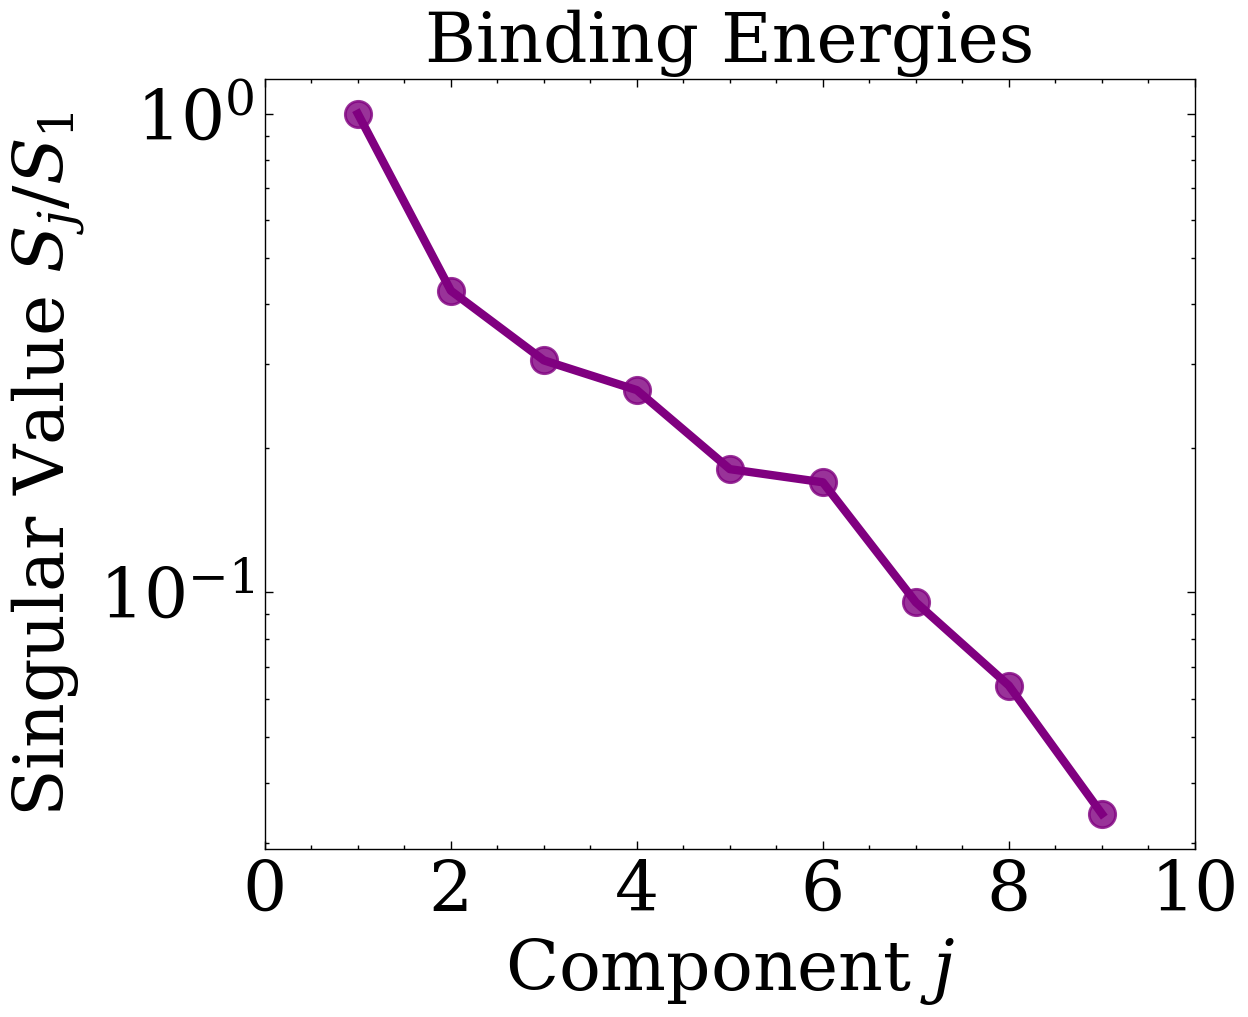

In [28]:
U, S, Vt = np.linalg.svd(model_predictions_mass_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Binding Energies', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Singular Values/Singular Values - Mass Calibration.png')
plt.show()

In [29]:
U.shape 

(300, 300)

In [24]:
def PC_RMSE_calculator_mass(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_mass_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_mass_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    # real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_mass_train['truth'])-predictions_mean_mass_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_mass_train.T)
    supermodel_validation = model_weights.dot(model_predictions_mass_validation.T)
    supermodel_test = model_weights.dot(model_predictions_mass_test.T)
    supermodel_full = model_weights.dot(model_predictions_mass.T)
    
    supermodel_residuals_train=supermodel_train-models_output_mass_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_mass_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_mass_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_mass['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [25]:
def PC_RMSE_calculator_radius(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_mass_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_mass_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    # real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_mass_train['truth'])-predictions_mean_mass_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_radius_train.T)
    supermodel_validation = model_weights.dot(model_predictions_radius_validation.T)
    supermodel_test = model_weights.dot(model_predictions_radius_test.T)
    supermodel_full = model_weights.dot(model_predictions_radius.T)
    
    supermodel_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [26]:
centering_data = True
if centering_data:
    s_mass_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_mass_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_mass_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_mass_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_mass(i)
        s_mass_train.append(res[0])
        s_mass_validation.append(res[1])
        s_mass_test.append(res[2])
        
        s_mass_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

In [27]:
centering_data = True
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_radius(i)
        s_radius_train.append(res[0])
        s_radius_validation.append(res[1])
        s_radius_test.append(res[2])
        
        s_radius_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

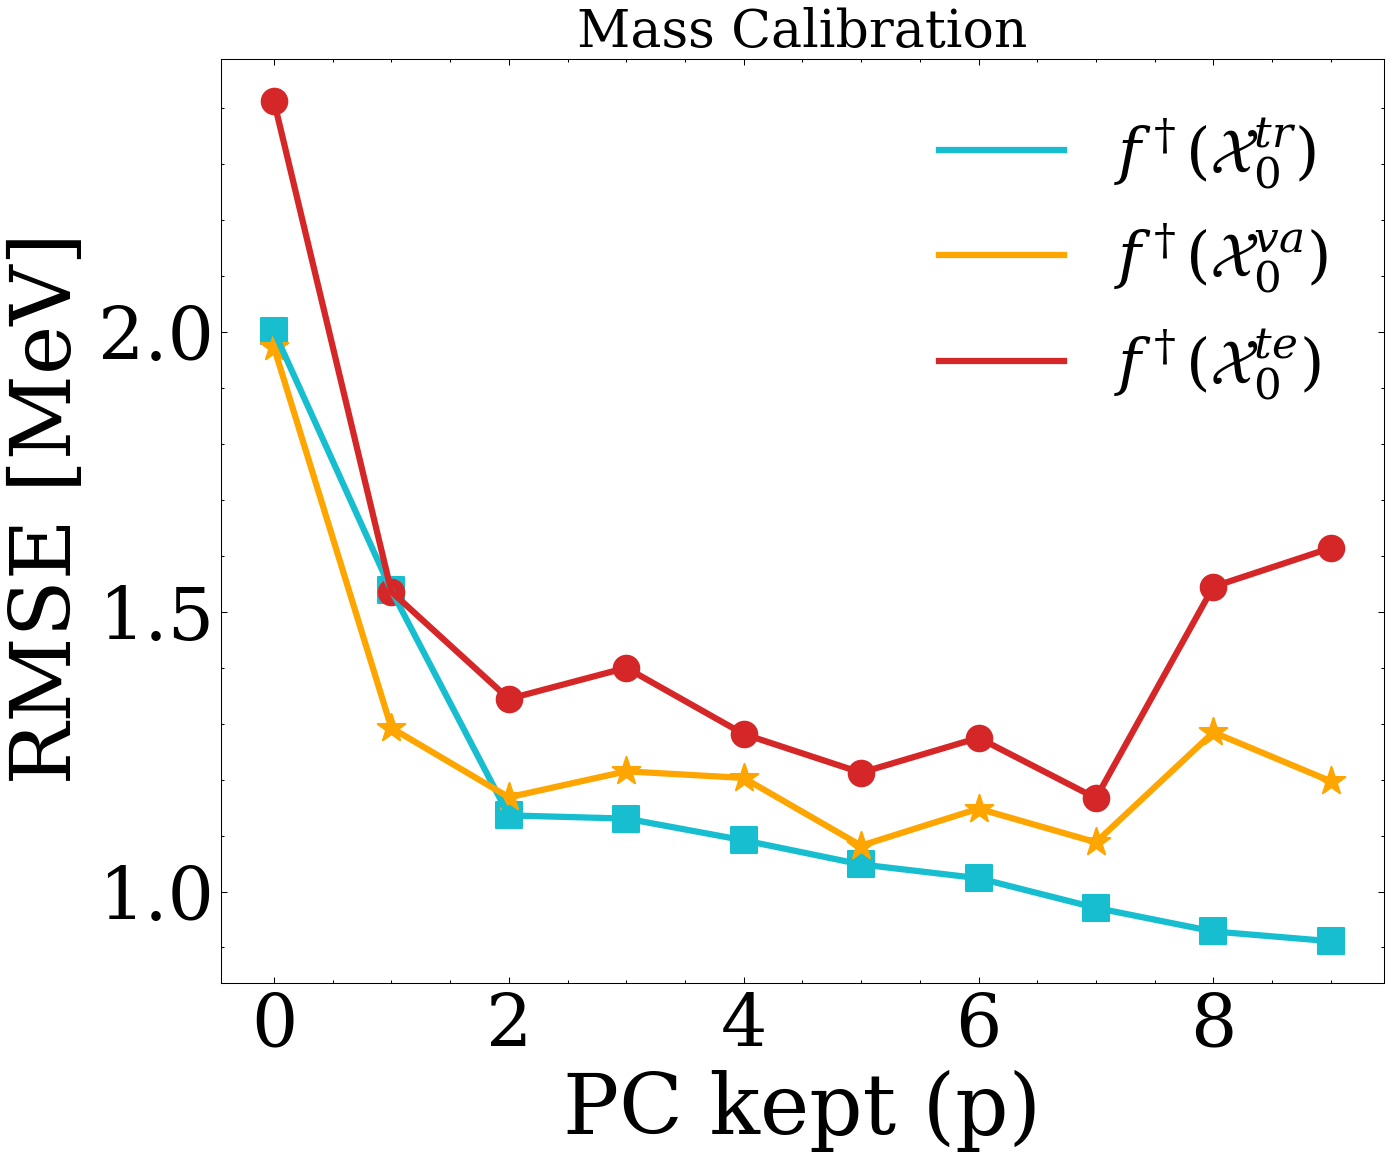

In [28]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
plt.title('Mass Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Mass RMSE decay - Mass Analysis.png')
plt.legend(fontsize=30)
plt.show()

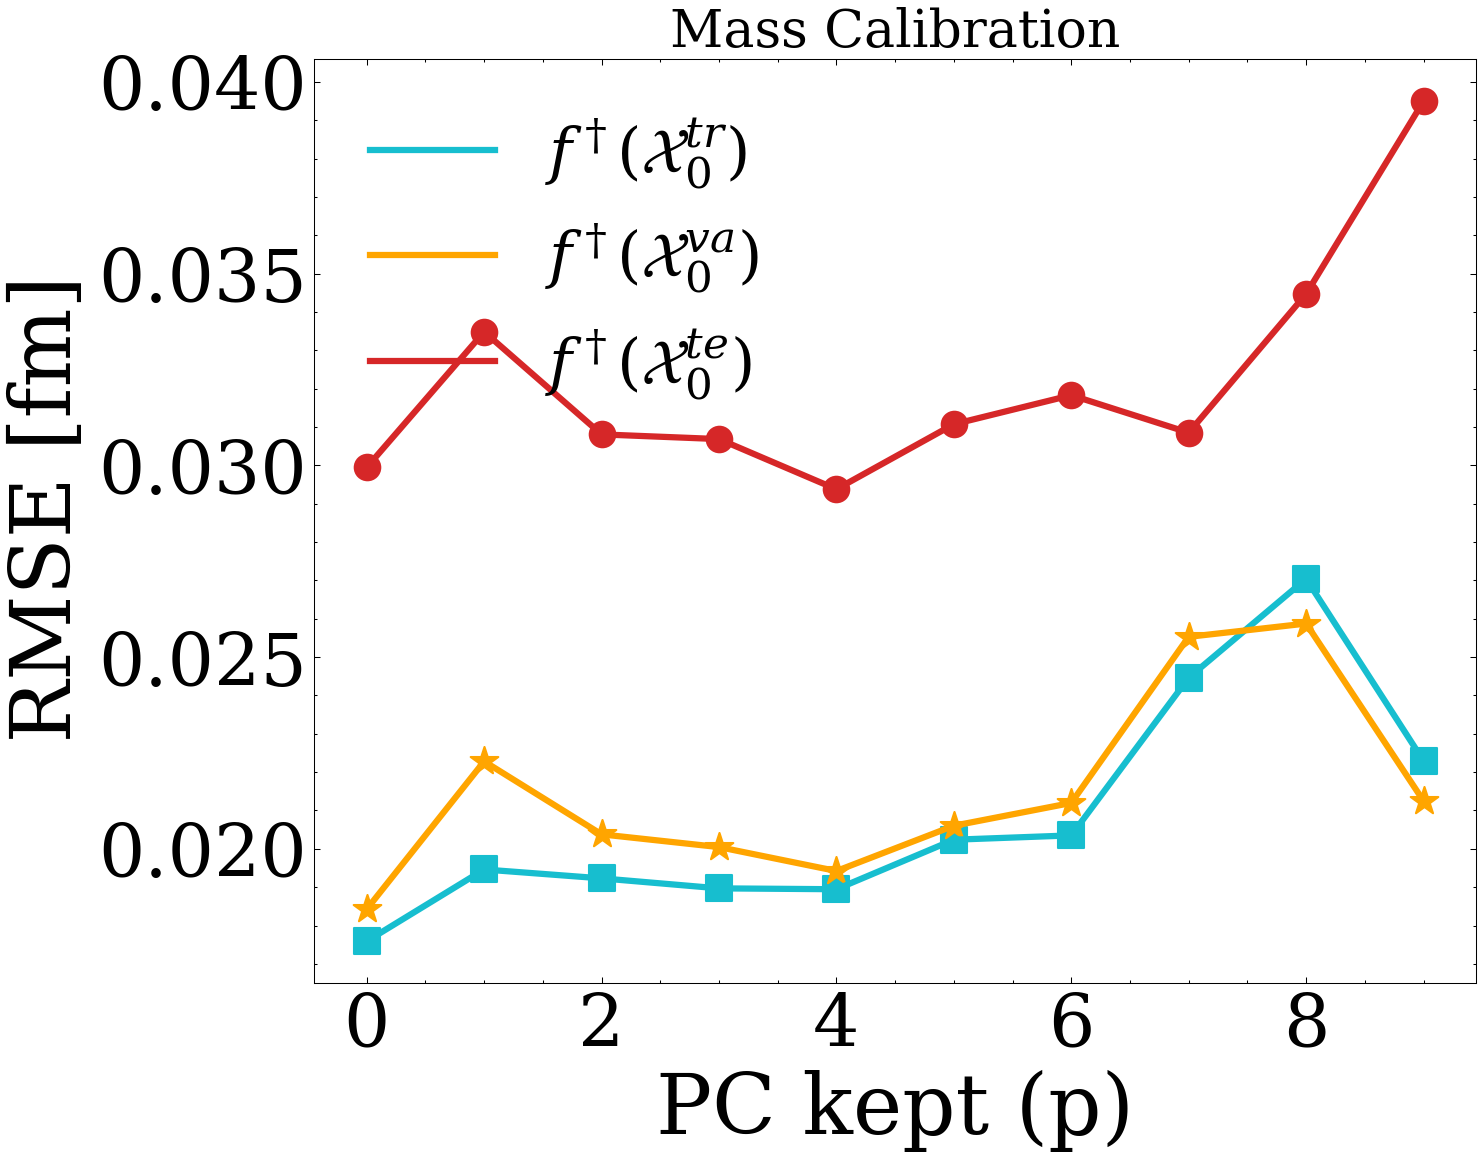

In [29]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Mass Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Mass Analysis.png')
plt.legend(fontsize=30)
plt.show()

In [30]:
components_kept = 2
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [31]:
models_PC_mass = models_PC_output(Vt_hat, model_predictions_mass, predictions_mean_mass)
models_PC_mass_train = models_PC_output(Vt_hat, model_predictions_mass_train, predictions_mean_mass_train)
models_PC_mass_validation = models_PC_output(Vt_hat, model_predictions_mass_validation, predictions_mean_mass_validation)
models_PC_mass_test = models_PC_output(Vt_hat, model_predictions_mass_test, predictions_mean_mass_test)

In [32]:
models_PC_mass_train

,PC_0,PC_1,PC_2
0,127.471605,-0.034962,-0.027119
1,141.937856,-0.056097,0.012806
2,153.795002,-0.071713,0.038960
3,134.555183,-0.060155,0.032535
4,157.290193,-0.051110,0.026909
...,...,...,...
295,1786.600059,0.095031,0.051666
296,1797.703324,0.090908,0.064495
297,1808.256735,0.090575,0.071956
298,1784.836690,0.124547,0.017113


### The first plots we are going to show is the plots of projections of models onto the PCs. We will compare this graph between the 3 cases to see if there is any discrepancies between the 3 analysis

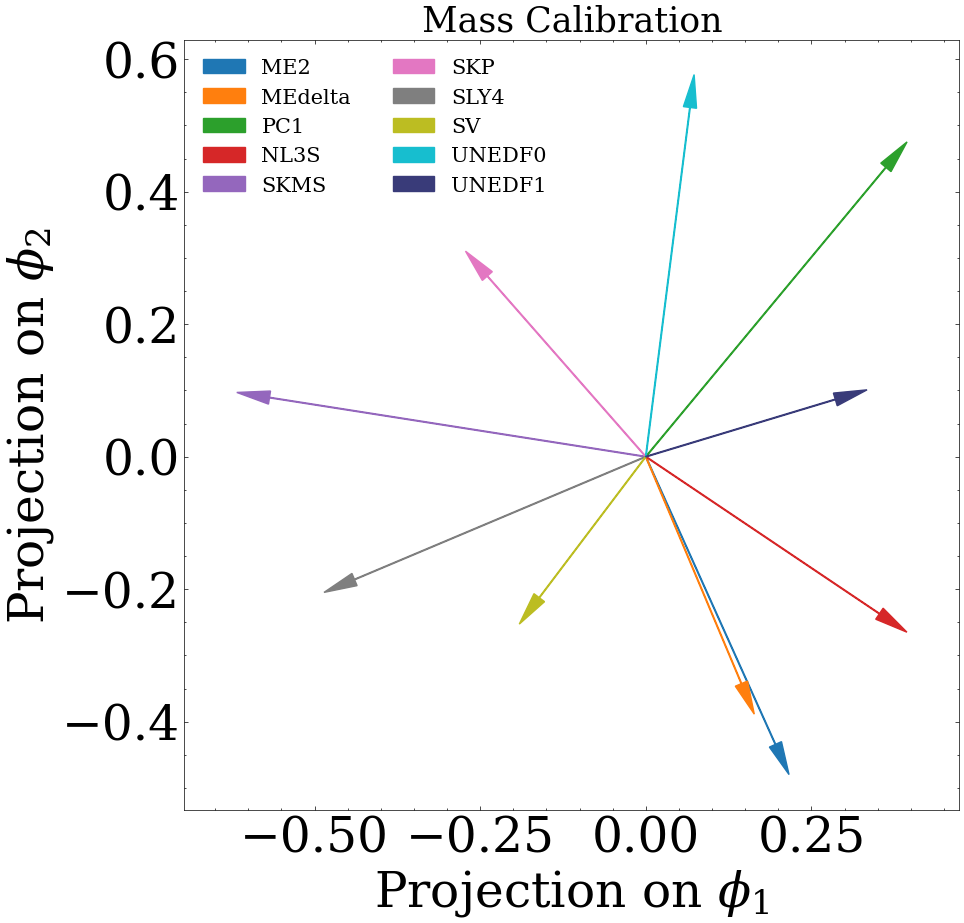

In [88]:

plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,10), dpi=100)


visited_model=0
for model in key_list:
    ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
            head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=model)
#     plt.text(Vt_hat_normalized.T[visited_model][0], Vt_hat_normalized.T[visited_model][1], model,fontsize=20,ha='center', va='center')    
    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #     head_width=0.02, head_length=0.05, fc='w', ec='w',label=model)

    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #         head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=str(visited_model))

    visited_model=visited_model+1



plt.xlabel('Projection on $\phi_1$',fontsize=35)
plt.ylabel('Projection on $\phi_2$',fontsize=35)

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)


plt.legend(fontsize=15,ncols=2)
# ax.set_xticks([-0.2,0,0.2,0.4,0.6])
plt.axis('equal')
# plt.xlim(-0.25, 0.6)
# plt.ylim(-0.43, 0.5)
plt.title('Mass Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/PCs projections/Projections on PCs - Mass Analysis.png')

plt.show()


In [34]:
X = np.copy(U_hat)

y_mass = models_output_mass_train['truth'] - predictions_mean_mass_train
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train
y = np.hstack((y_mass,y_radius))

X_train = models_PC_mass_train.values
X_validation = models_PC_mass_validation.values
X_test = models_PC_mass_test.values
X_full = models_PC_mass.values

## We will now consider the both unconstrained and simplex-constrained sampling method

### Unconstrained

In [35]:
nu0_chosen=10
sigma20_chosen=0.5

In [36]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [37]:
samples = gibbs_sampler(y_mass,X, 500000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

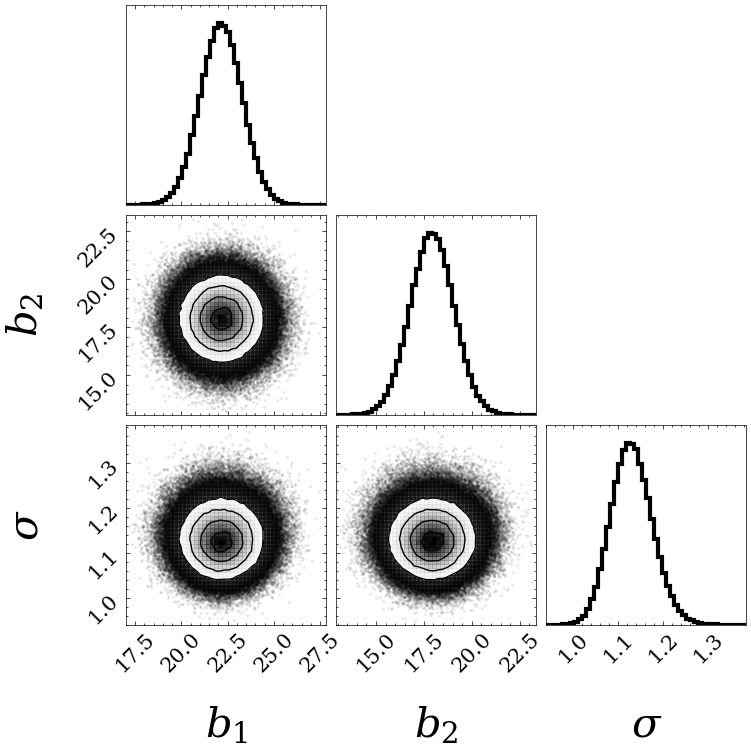

In [38]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [39]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [40]:
filtered_model_predictions_mass_50 = filtered_models_output_mass_50.iloc[:,3:-1].values

In [41]:
lower_mass, median_mass, upper_mass = rndm_m_radius_calculator(model_weights, filtered_model_predictions_mass_50, samples)

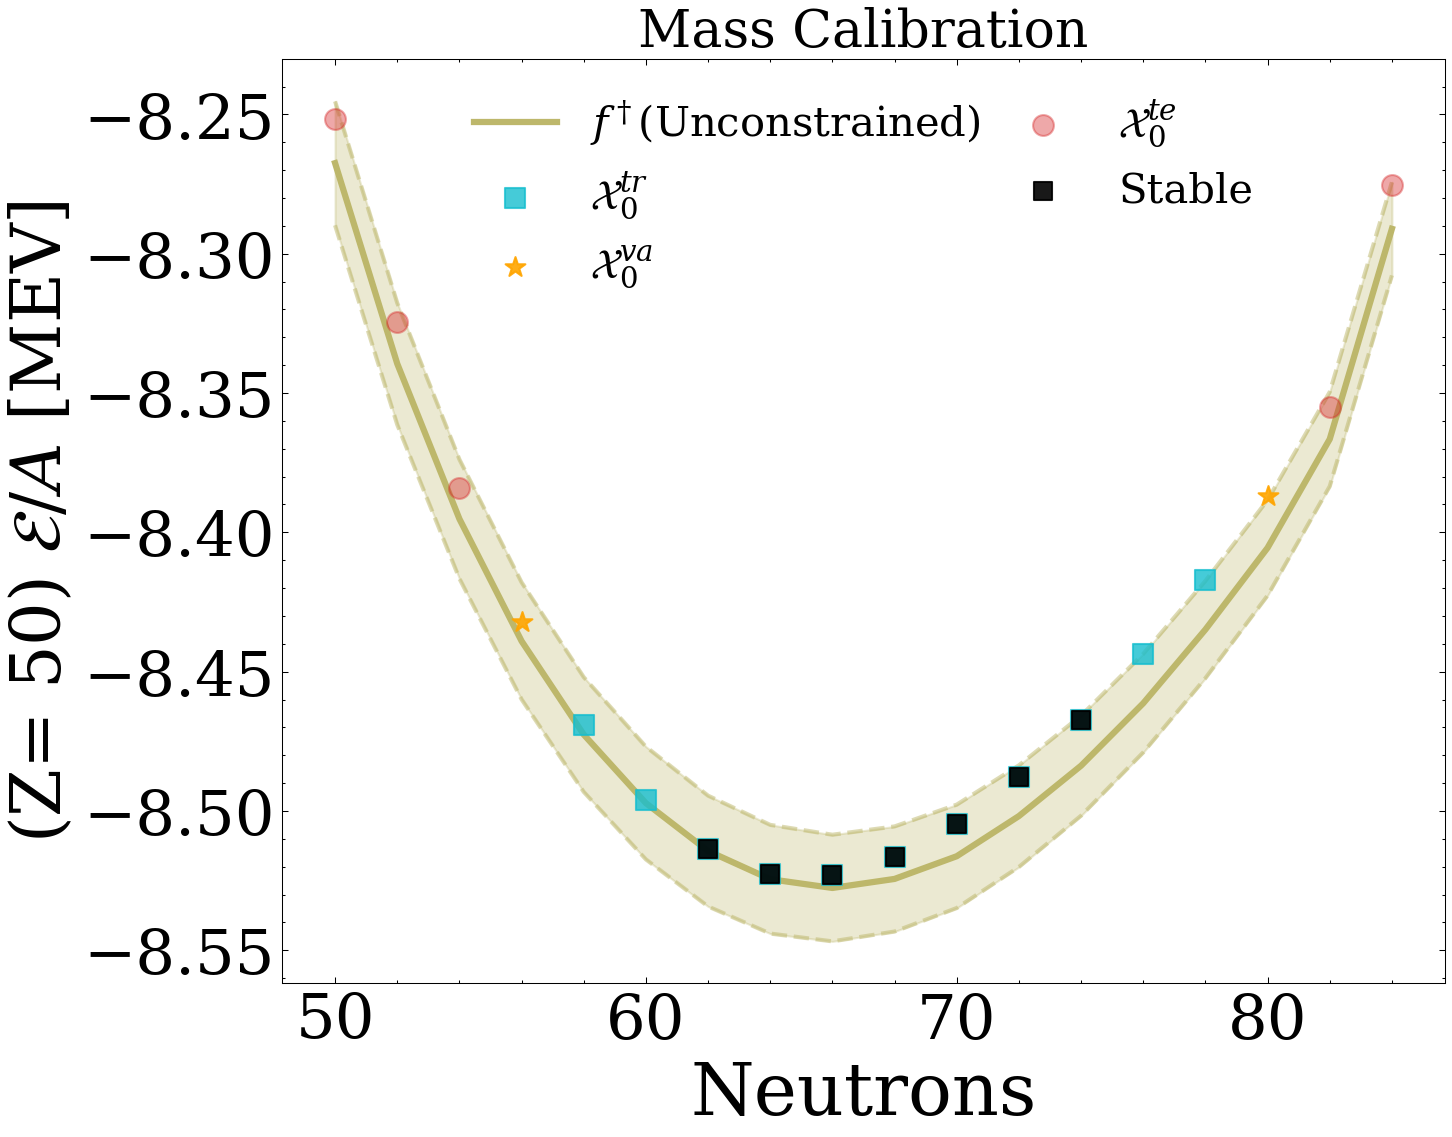

In [95]:
supermodel_predictions_mass_range = [lower_mass, median_mass, upper_mass]
# title = 'Mass Calibration'
# savefig_50_mass = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Unconstrained BE forecasts for Z = 50 - Mass Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_mass_range, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Unconstrained',title, savefig_50_mass)

In [43]:
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

In [44]:
# We need to find a way to quantify the uncertainty for the radius. In this case, what we are going to do is to use the RMSE
# calculated from the training data sets when we use the mean value of the parameters we samples to make our predictions

In [45]:
model_weights.shape
model_weights_mean = np.mean(model_weights, axis = 0)

radius_predictions_mean = np.dot(model_weights_mean, model_predictions_radius_train.T)
sigma_naive_radius = np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-radius_predictions_mean)/np.sqrt(len(radius_predictions_mean))
sigma_naive_radius

0.01922957369235669

In [46]:
rndm_m_radius = []
for i in range(len(model_weights)):
    if centering_data:
        yvals_rand_radius= filtered_model_predictions_radius_20.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * sigma_naive_radius**2 ) )))  
        
lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

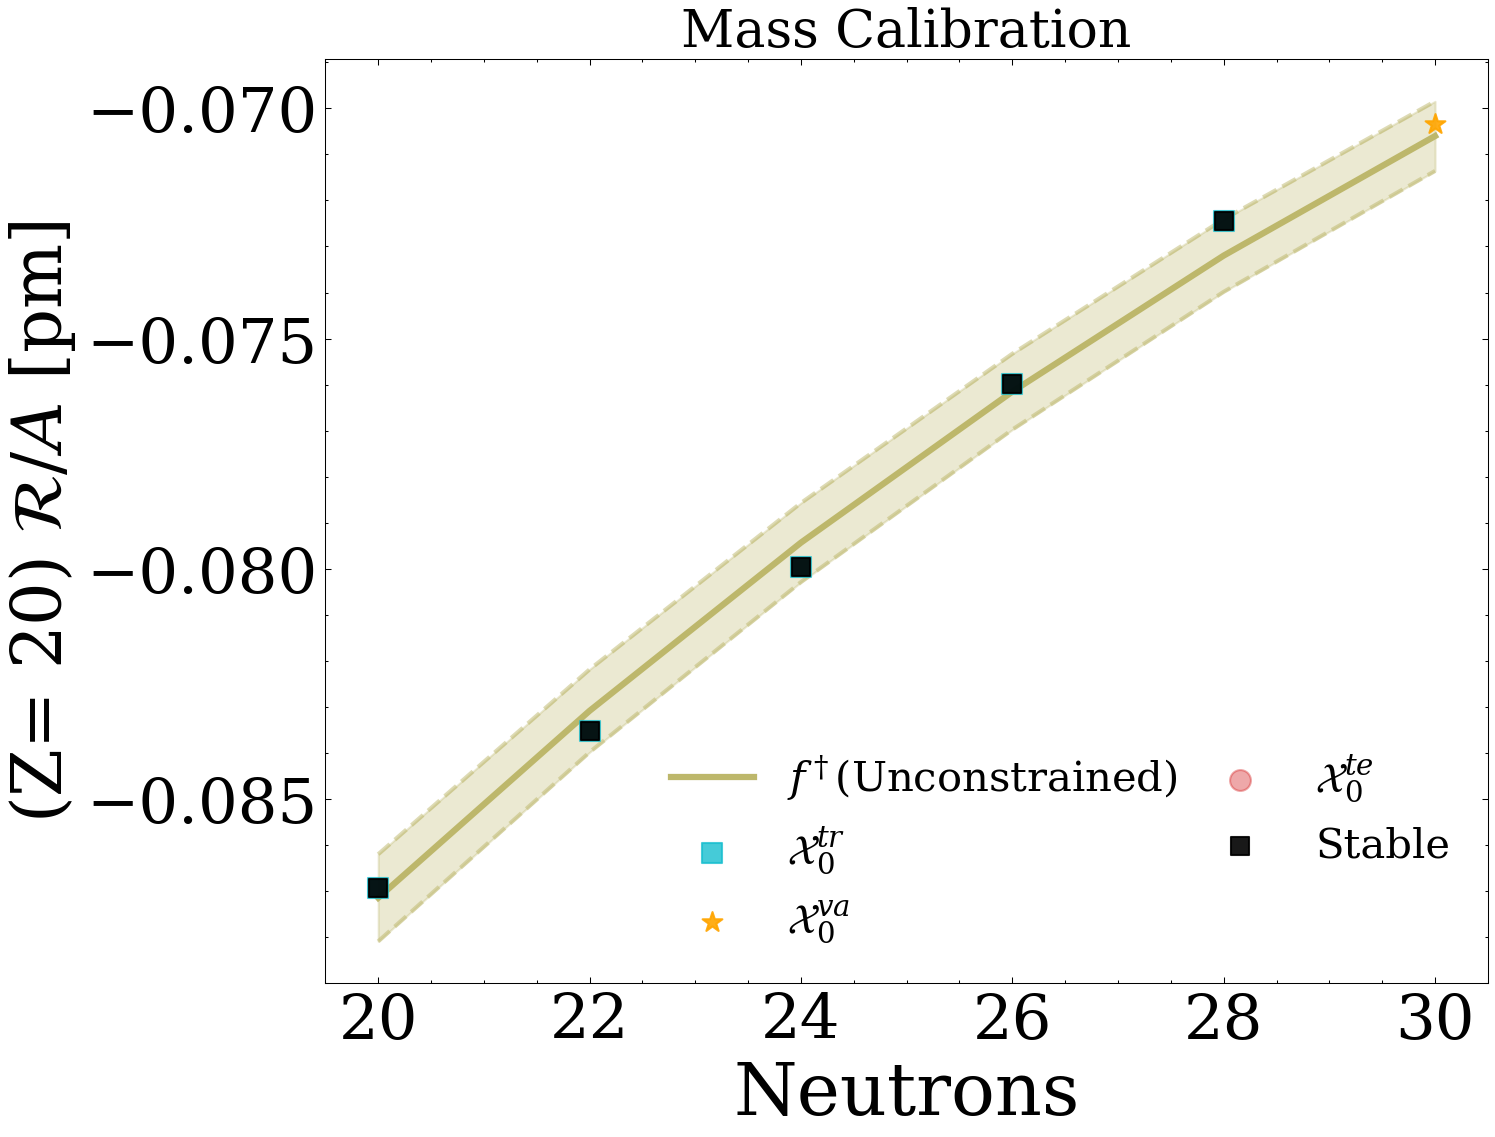

In [96]:
supermodel_predictions_radius_range = [lower_radius, median_radius, upper_radius]
# title = 'Mass Calibration'
# savefig_50_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 50 - Mass Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range, filtered_models_output_radius_list_20, 20, 'pm', 'R', 'Unconstrained', title, savefig_50_radius)

## Simplex

In [48]:
nu0_chosen=10
sigma20_chosen=0.5
bias0=np.full(len(model_predictions_mass_train.T),1/len(model_predictions_mass_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data

In [49]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [50]:
%%time
samples_simplex=gibbs_sampler_simplex(y_mass, X.T, 500000,[nu0_chosen, sigma20_chosen],burn=300000,stepsize=0.003)

percentage accepted: 22
CPU times: total: 4min 28s
Wall time: 1h 29min 13s


In [51]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

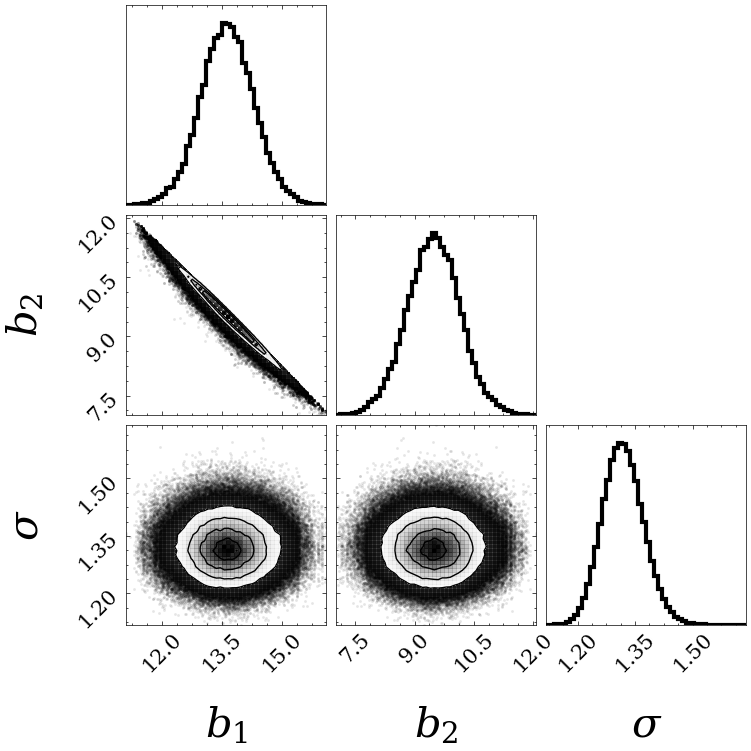

In [52]:
plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [53]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex = np.array(model_weights_simplex)

In [54]:
lower_mass_simplex, median_mass_simplex, upper_mass_simplex = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_50, samples_simplex)

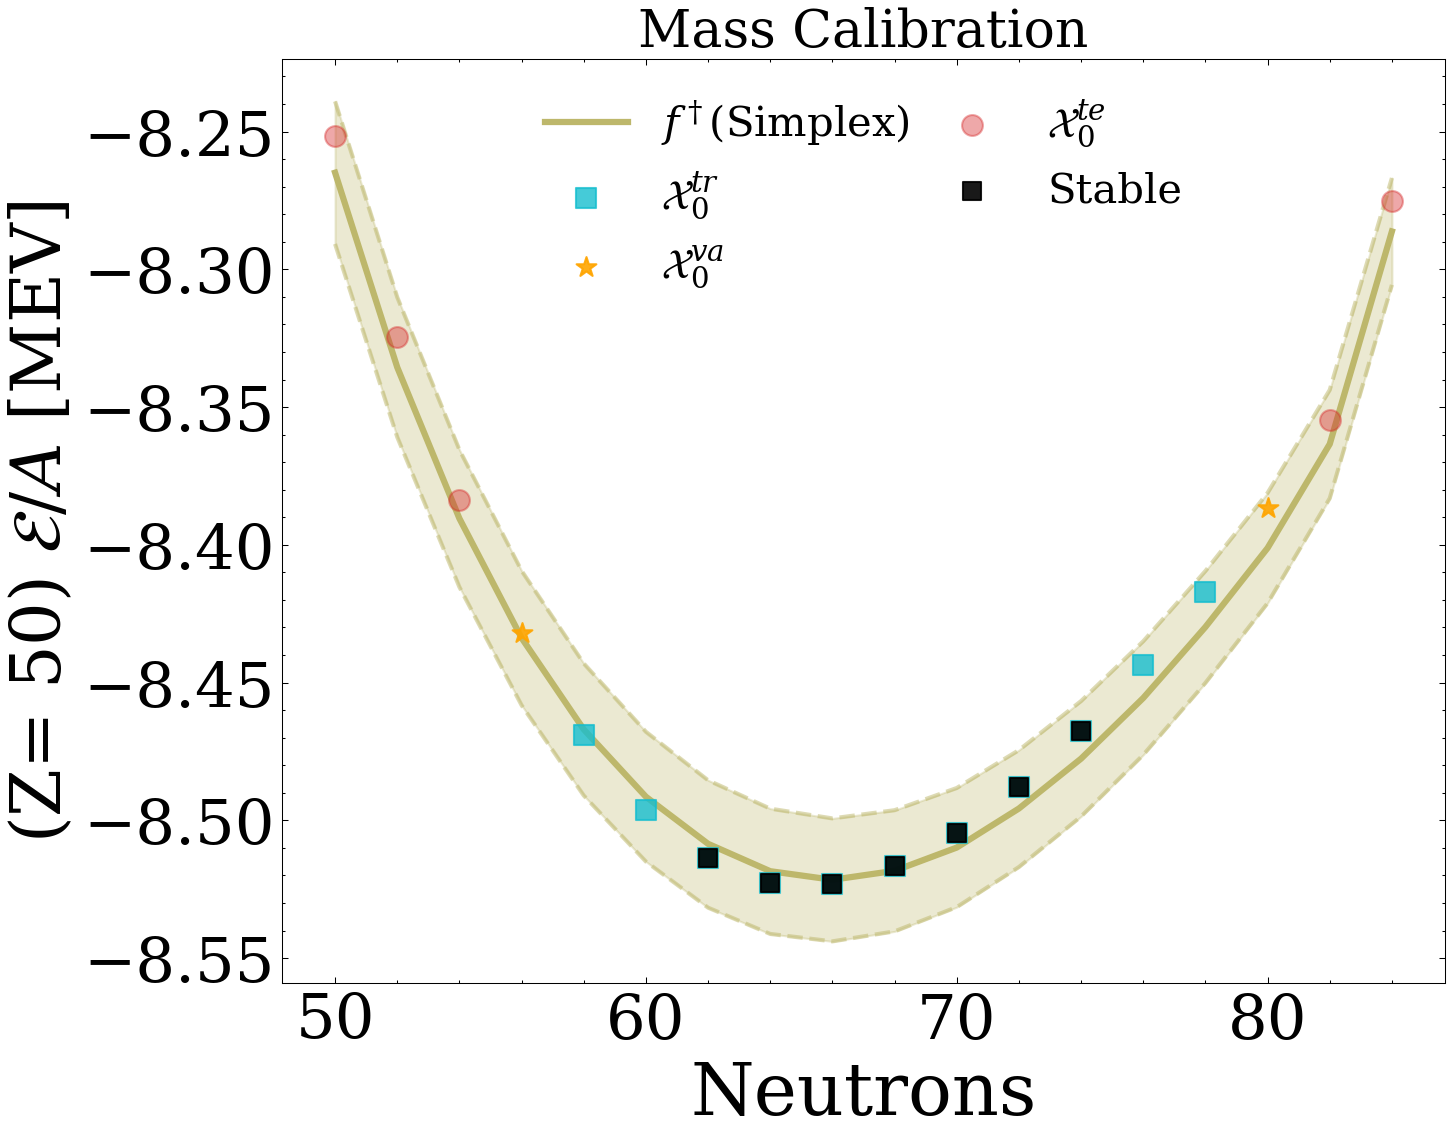

In [97]:
supermodel_predictions_mass_range_simplex = [lower_mass_simplex, median_mass_simplex, upper_mass_simplex]
# title = 'Mass Calibration'
# savefig_50_mass_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Simplex BE forecasts for Z = 50 - Mass Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Simplex', title, savefig_50_mass_simplex)

In [56]:
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

In [57]:
model_weights_simplex.shape
model_weights_mean_simplex = np.mean(model_weights_simplex, axis = 0)

radius_predictions_mean_simplex = np.dot(model_weights_mean_simplex, model_predictions_radius_train.T)
sigma_naive_radius_simplex = np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-radius_predictions_mean_simplex)/np.sqrt(len(radius_predictions_mean_simplex))
sigma_naive_radius_simplex

0.01848171128025765

In [58]:
rndm_m_radius_simplex = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_radius= filtered_model_predictions_radius_20.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_radius_simplex.append(yvals_rand_radius +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_radius)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * sigma_naive_radius_simplex**2 ) )))  
lower_radius_simplex = np.percentile(rndm_m_radius_simplex, 2.5, axis = 0)
median_radius_simplex = np.percentile(rndm_m_radius_simplex, 50, axis = 0)
upper_radius_simplex = np.percentile(rndm_m_radius_simplex, 97.5, axis = 0)

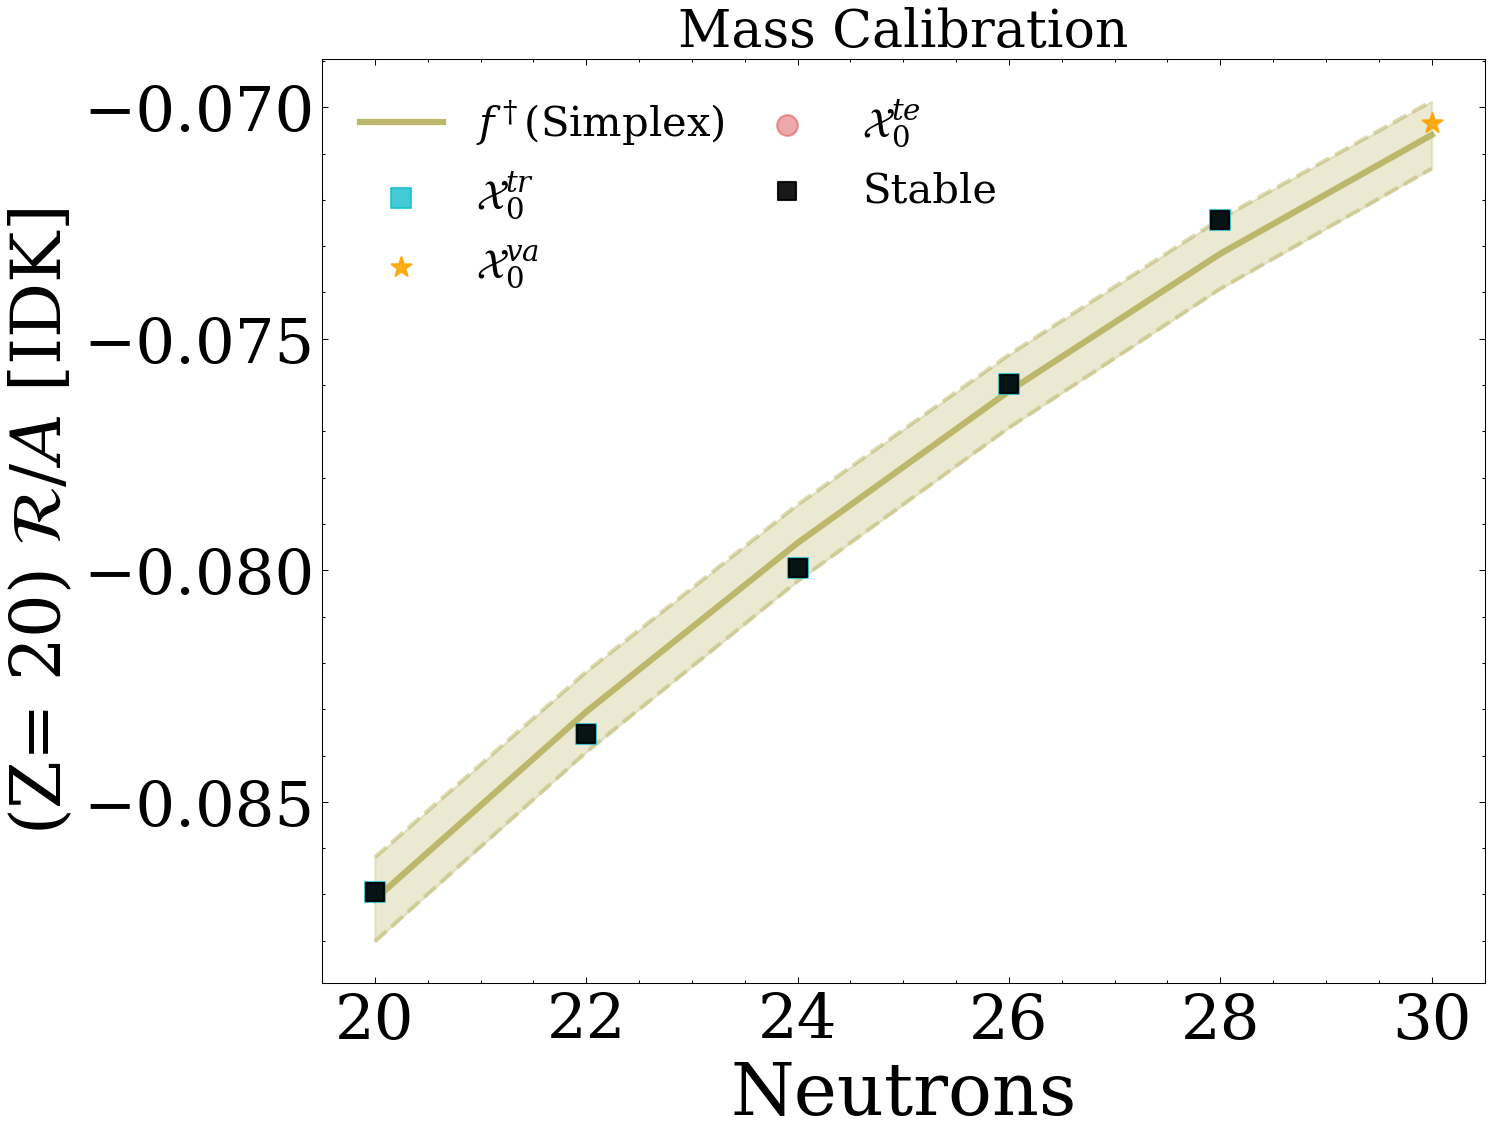

In [98]:
supermodel_predictions_radius_range_simplex = [lower_radius_simplex, median_radius_simplex, upper_radius_simplex]
title = 'Mass Calibration'
savefig_20_radius_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Simplex CR forecasts for Z = 20 - Mass Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex, filtered_models_output_radius_list_20, 20, 'IDK', 'R', 'Simplex', title, savefig_20_radius_simplex)

# Z = 60

In [278]:
# filtered_models_output_mass_list_60 = filtered_models_output(60, models_output_mass_list)
# filtered_models_output_radius_list_60 = filtered_models_output(60, models_output_radius_list)

# filtered_models_output_mass_60 = filtered_models_output_mass_list_60[0]
# filtered_models_output_radius_60 = filtered_models_output_radius_list_60[0]

# filtered_model_predictions_mass_60 = filtered_models_output_mass_60.iloc[:,3:-1].values
# filtered_model_predictions_radius_60 = filtered_models_output_radius_60.iloc[:,3:-1].values

In [279]:
# lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_60, samples_simplex)

In [280]:
# rndm_m_radius_simplex_60 = []
# for i in range(len(model_weights_simplex)):
#     if centering_data:
#         yvals_rand_radius_60= filtered_model_predictions_radius_60.dot(model_weights_simplex[i].T)
#     # else:
#     #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

#     rndm_m_radius_simplex_60.append(yvals_rand_radius_60 +
#                    np.random.multivariate_normal(np.full(
#                        len(yvals_rand_radius_60)
#                        ,0), np.diag(1.0 * np.full(len(yvals_rand_radius_60),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
# lower_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 2.5, axis = 0)
# median_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 50, axis = 0)
# upper_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 97.5, axis = 0)

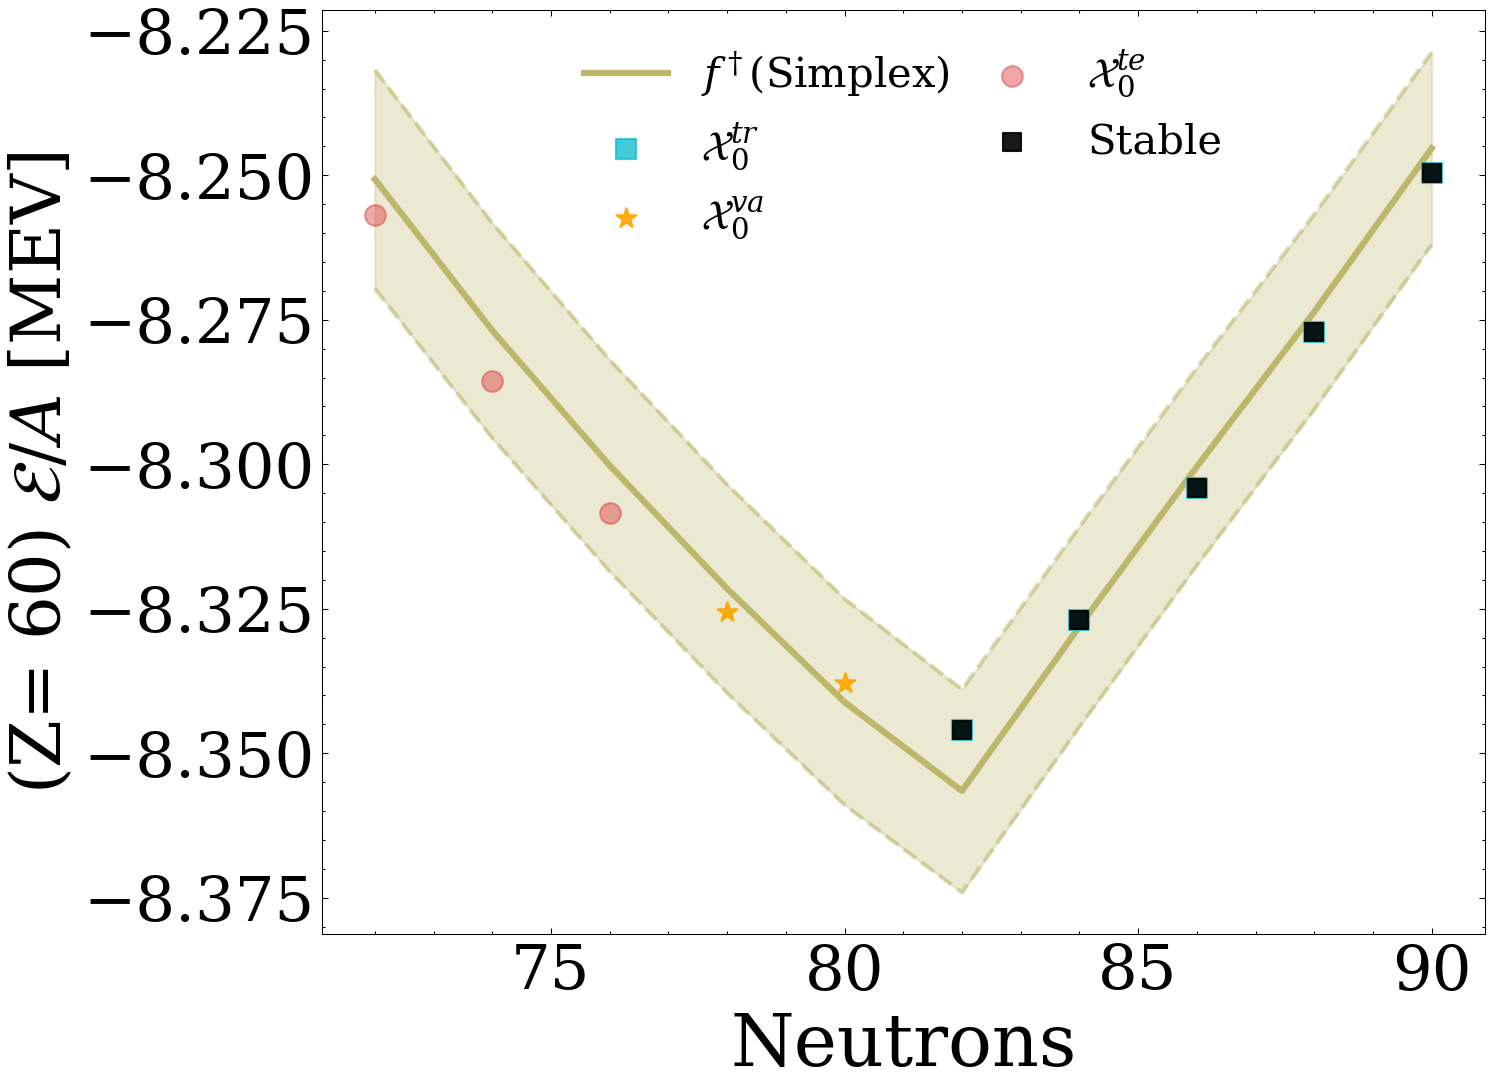

In [311]:
# supermodel_predictions_mass_range_simplex_60 = [lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60]
# savefig_60_mass_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Mass forecasts for Z = 60 in Heterogeneous Mass Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_60, filtered_models_output_mass_list_60, 60, 'MEV', 'E', 'Simplex', savefig_60_mass_simplex)

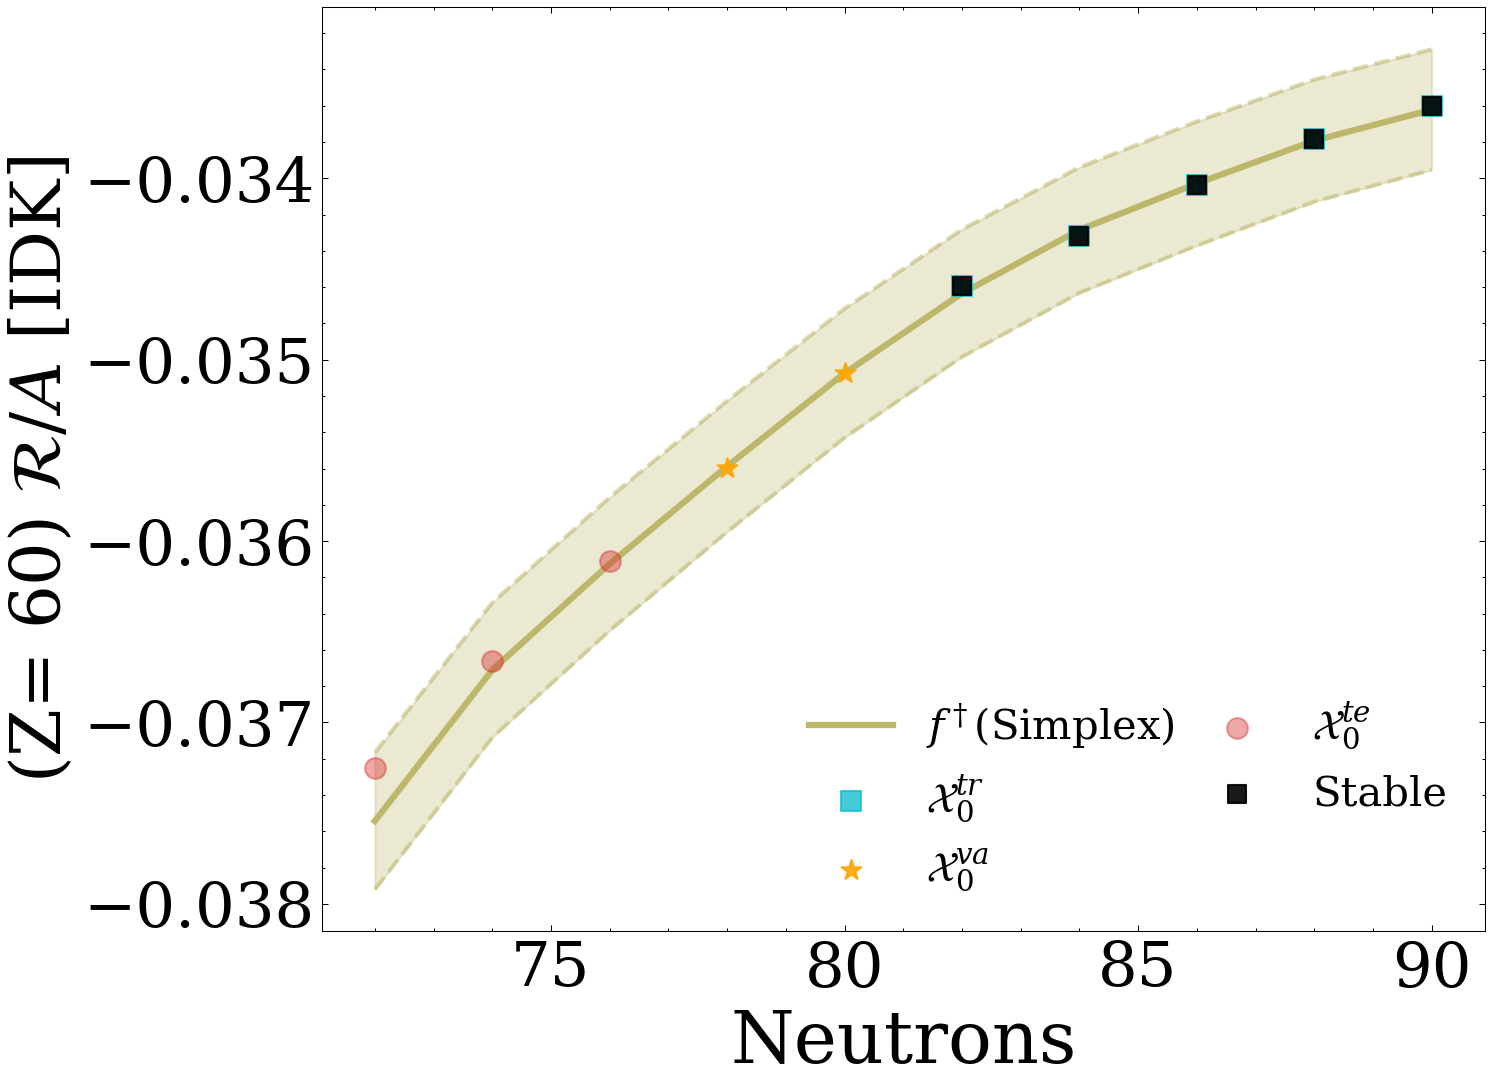

In [312]:
# supermodel_predictions_radius_range_simplex_60 = [lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60]
# savefig_60_radius_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Radius forecasts for Z = 60 in Heterogeneous Mass Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_60, filtered_models_output_radius_list_60, 60, 'IDK', 'R', 'Simplex', savefig_60_radius_simplex)

# Z = 80

In [283]:
# filtered_models_output_mass_list_80 = filtered_models_output(80, models_output_mass_list)
# filtered_models_output_radius_list_80 = filtered_models_output(80, models_output_radius_list)

# filtered_models_output_mass_80 = filtered_models_output_mass_list_80[0]
# filtered_models_output_radius_80 = filtered_models_output_radius_list_80[0]

# filtered_model_predictions_mass_80 = filtered_models_output_mass_80.iloc[:,3:-1].values
# filtered_model_predictions_radius_80 = filtered_models_output_radius_80.iloc[:,3:-1].values

In [284]:
# lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_80, samples_simplex)

In [285]:
# rndm_m_radius_simplex_80 = []
# for i in range(len(model_weights_simplex)):
#     if centering_data:
#         yvals_rand_radius_80= filtered_model_predictions_radius_80.dot(model_weights_simplex[i].T)
#     # else:
#     #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

#     rndm_m_radius_simplex_80.append(yvals_rand_radius_80 +
#                    np.random.multivariate_normal(np.full(
#                        len(yvals_rand_radius_80)
#                        ,0), np.diag(1.0 * np.full(len(yvals_rand_radius_80),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
# lower_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 2.5, axis = 0)
# median_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 50, axis = 0)
# upper_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 97.5, axis = 0)

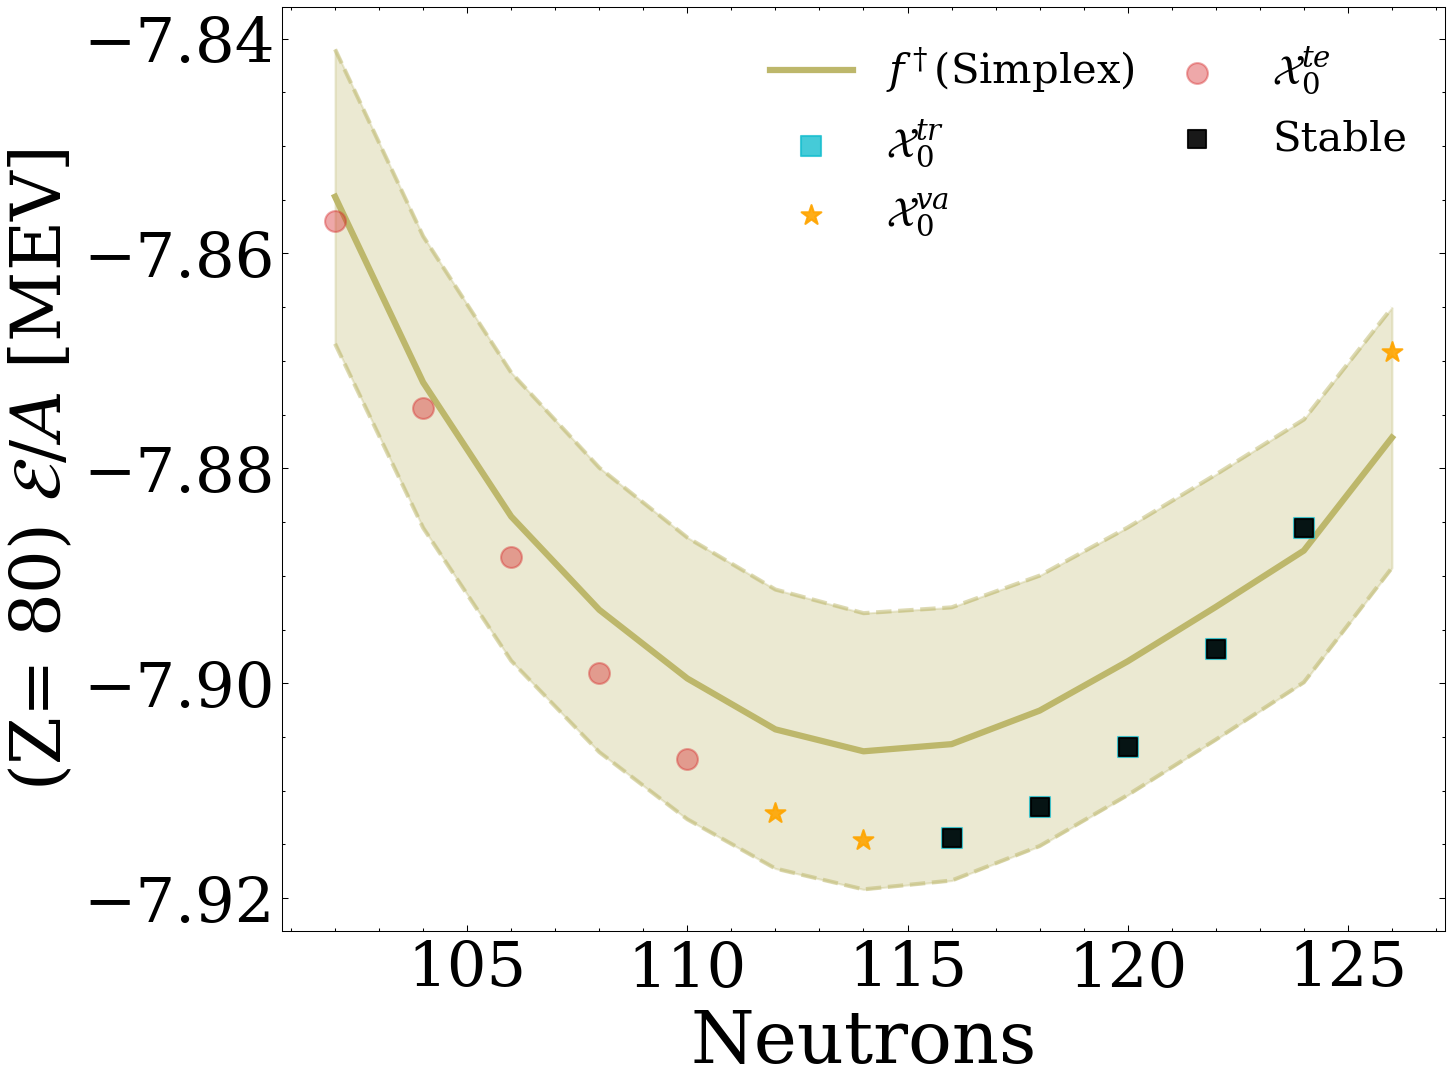

In [313]:
# supermodel_predictions_mass_range_simplex_80 = [lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80]
# savefig_80_mass_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Mass forecasts for Z = 80 in Heterogeneous Mass Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_80, filtered_models_output_mass_list_80, 80, 'MEV', 'E', 'Simplex', savefig_80_mass_simplex)

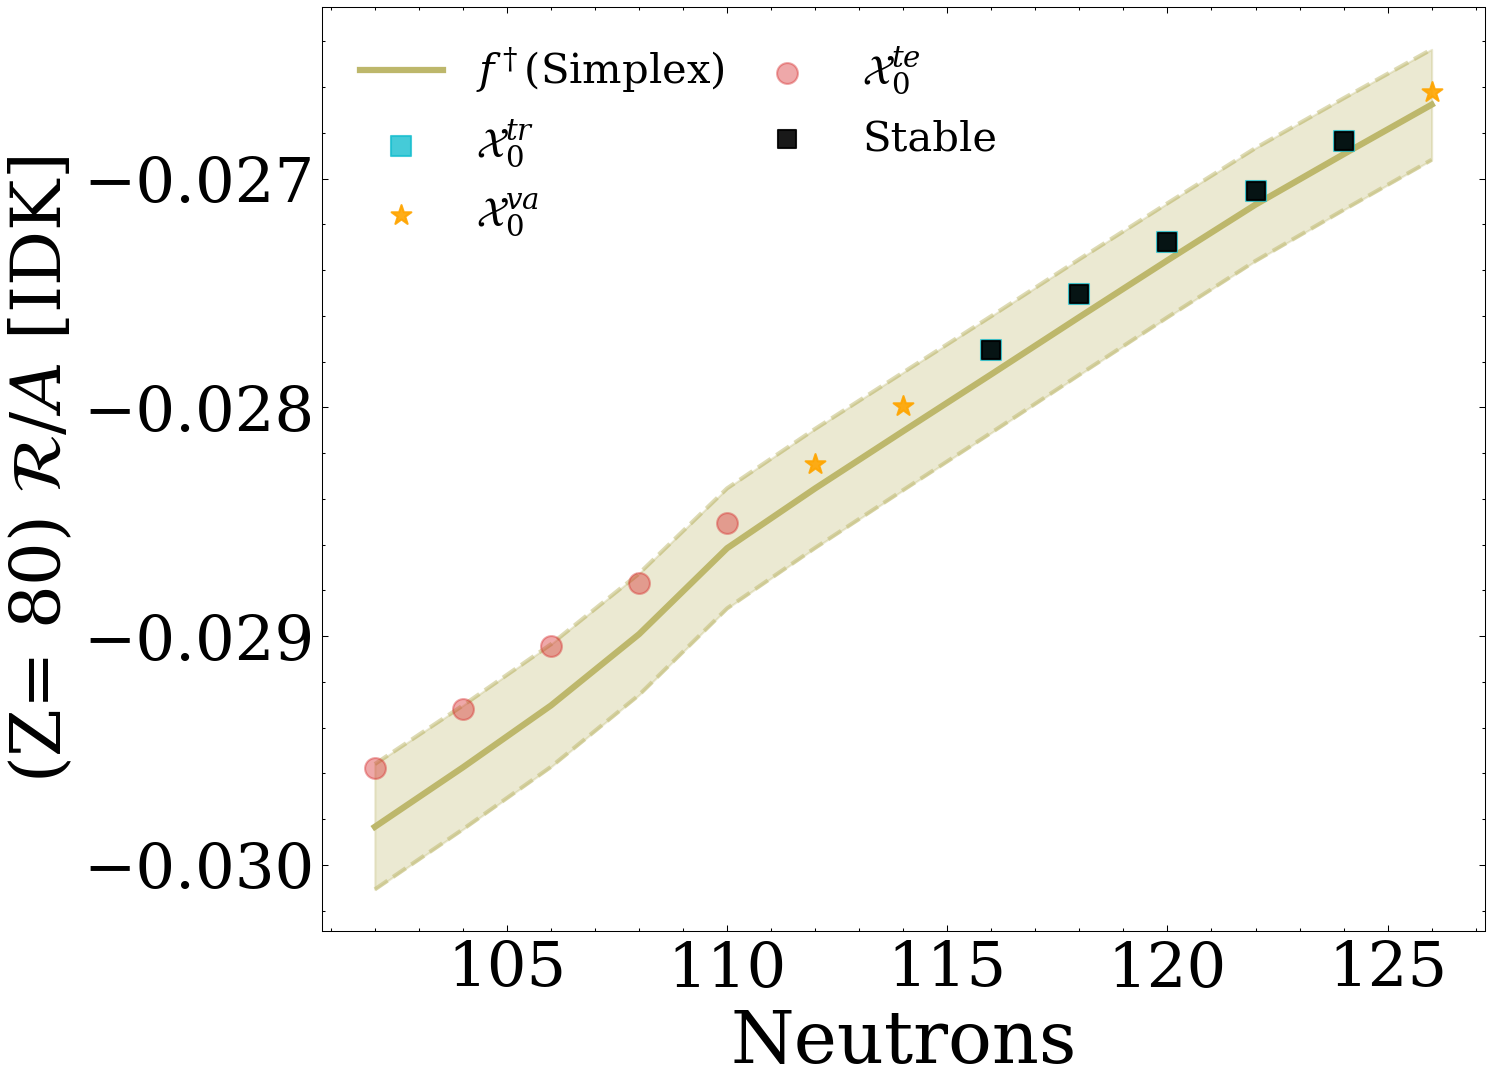

In [314]:
# supermodel_predictions_radius_range_simplex_80 = [lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80]
# savefig_80_radius_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Radius forecasts for Z = 80 in Heterogeneous Mass Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_80, filtered_models_output_radius_list_80, 80, 'IDK', 'R', 'Simplex', savefig_80_radius_simplex)

### The next step is to compare the weights of the models when calibrating using different properties

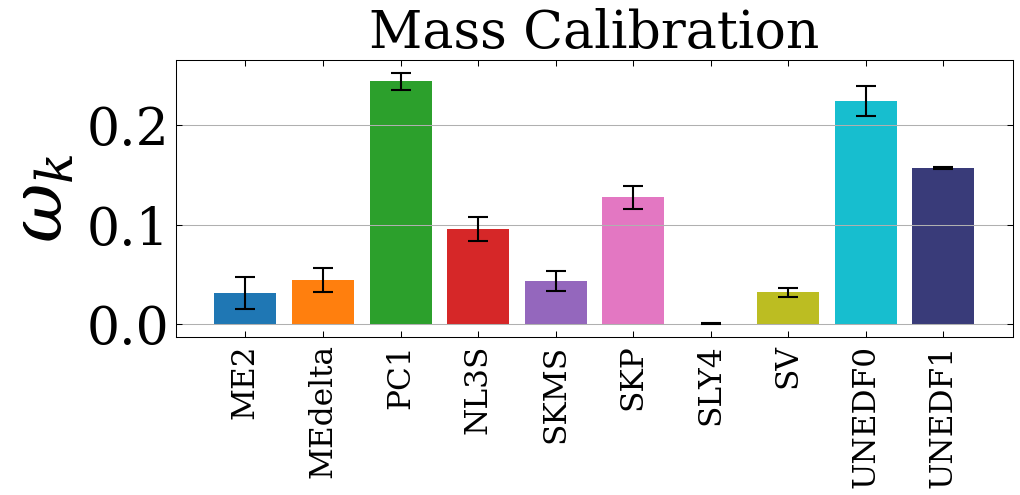

In [101]:
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
# labels=list(models_output.keys())
plt.figure(figsize=(7, 3.5),dpi=150)
# y_max=0.6


i=0
for model in key_list:
        
        # ax.plot(filtered_models_output["N"], filtered_models_output[key_list[model_index]], 
        #         label = n_Labels[class_index], color=colors[class_index],alpha = alpha_models,linewidth=5)
        # plt.bar(model , np.mean(samples_naive_space_sigma.T[i]), color=colors[i])
        plt.bar(model , 
                np.mean(model_weights_simplex, axis  = 0)[i],yerr=2*np.std(model_weights_simplex.T[i]),
                color=colors[i],capsize=5)
        i=i+1




# plt.xlabel('Models',fontsize=15)
# plt.title("c)",fontsize=25)
plt.minorticks_off()
plt.ylabel('$\omega_k$',fontsize=35)
# plt.ylim(0,0.45)
plt.xticks(fontsize=15,rotation='vertical')
plt.yticks(fontsize=25)
plt.grid(axis='y')
plt.title('Mass Calibration', fontsize = 25)
plt.tight_layout()
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Model weights/Simplex models weights - Mass Analysis - 2PCs.png')
plt.show()


## Let's evaluate how our analysis work for coverage of actual data

### One thing to remember with our analysis is that we have to quantify the uncertainty for radius 

In [61]:
rndm_m_full_mass_train_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:30<00:00, 55.45it/s]


In [62]:
rndm_m_full_mass_train_simplex.shape

(5000, 300)

In [63]:
rndm_m_full_mass_validation_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:07<00:00, 687.59it/s]


In [66]:
rndm_m_full_mass_test_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:55<00:00, 90.79it/s] 


In [67]:
rndm_m_full_radius_train_simplex = rndm_m_radius_calculator_coverage(sigma_naive_radius_simplex, model_predictions_radius_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:21<00:00, 228.74it/s]


In [68]:
rndm_m_full_radius_validation_simplex = rndm_m_radius_calculator_coverage(sigma_naive_radius_simplex, model_predictions_radius_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:03<00:00, 1259.72it/s]


In [69]:
rndm_m_full_radius_test_simplex = rndm_m_radius_calculator_coverage(sigma_naive_radius_simplex, model_predictions_radius_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:08<00:00, 579.22it/s]


In [70]:
coverage_mass_train_simplex = coverage_calculation(rndm_m_full_mass_train_simplex, models_output_mass_train)

In [71]:
coverage_mass_validation_simplex = coverage_calculation(rndm_m_full_mass_validation_simplex, models_output_mass_validation)

In [72]:
coverage_mass_test_simplex = coverage_calculation(rndm_m_full_mass_test_simplex, models_output_mass_test)

In [73]:
percentiles = np.arange(0,101,5)

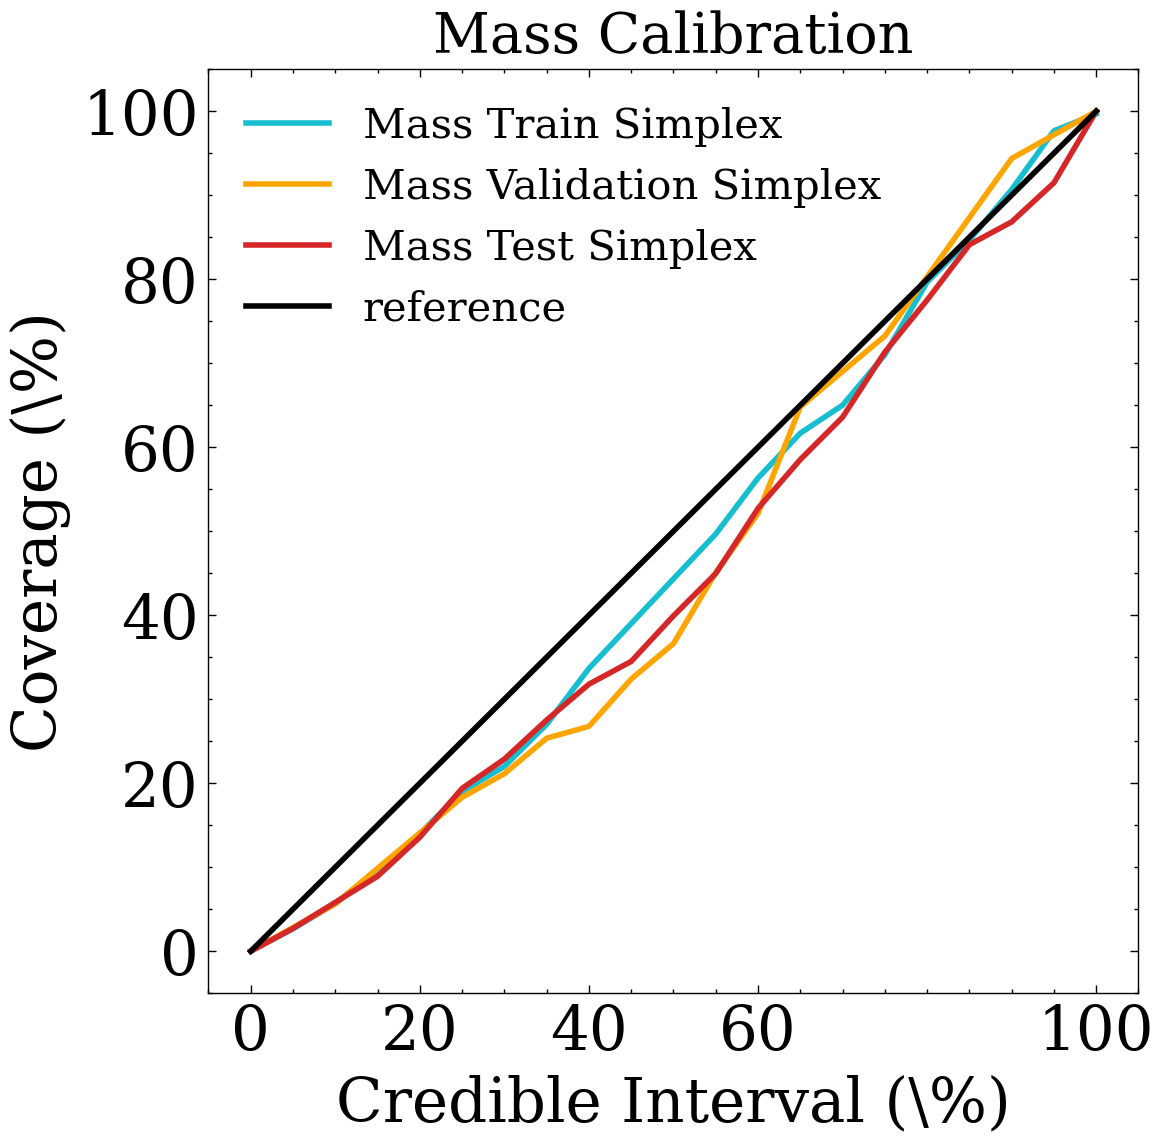

In [102]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_mass_train_simplex, label='Mass Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_mass_validation_simplex, label='Mass Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_mass_test_simplex, label='Mass Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Mass Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Mass ECP - Mass Analysis - 2PCs.png')
plt.show()

In [75]:
coverage_radius_train_simplex = coverage_calculation(rndm_m_full_radius_train_simplex, models_output_radius_train)

In [76]:
coverage_radius_validation_simplex = coverage_calculation(rndm_m_full_radius_validation_simplex, models_output_radius_validation)

In [78]:
coverage_radius_test_simplex = coverage_calculation(rndm_m_full_radius_test_simplex, models_output_radius_test)

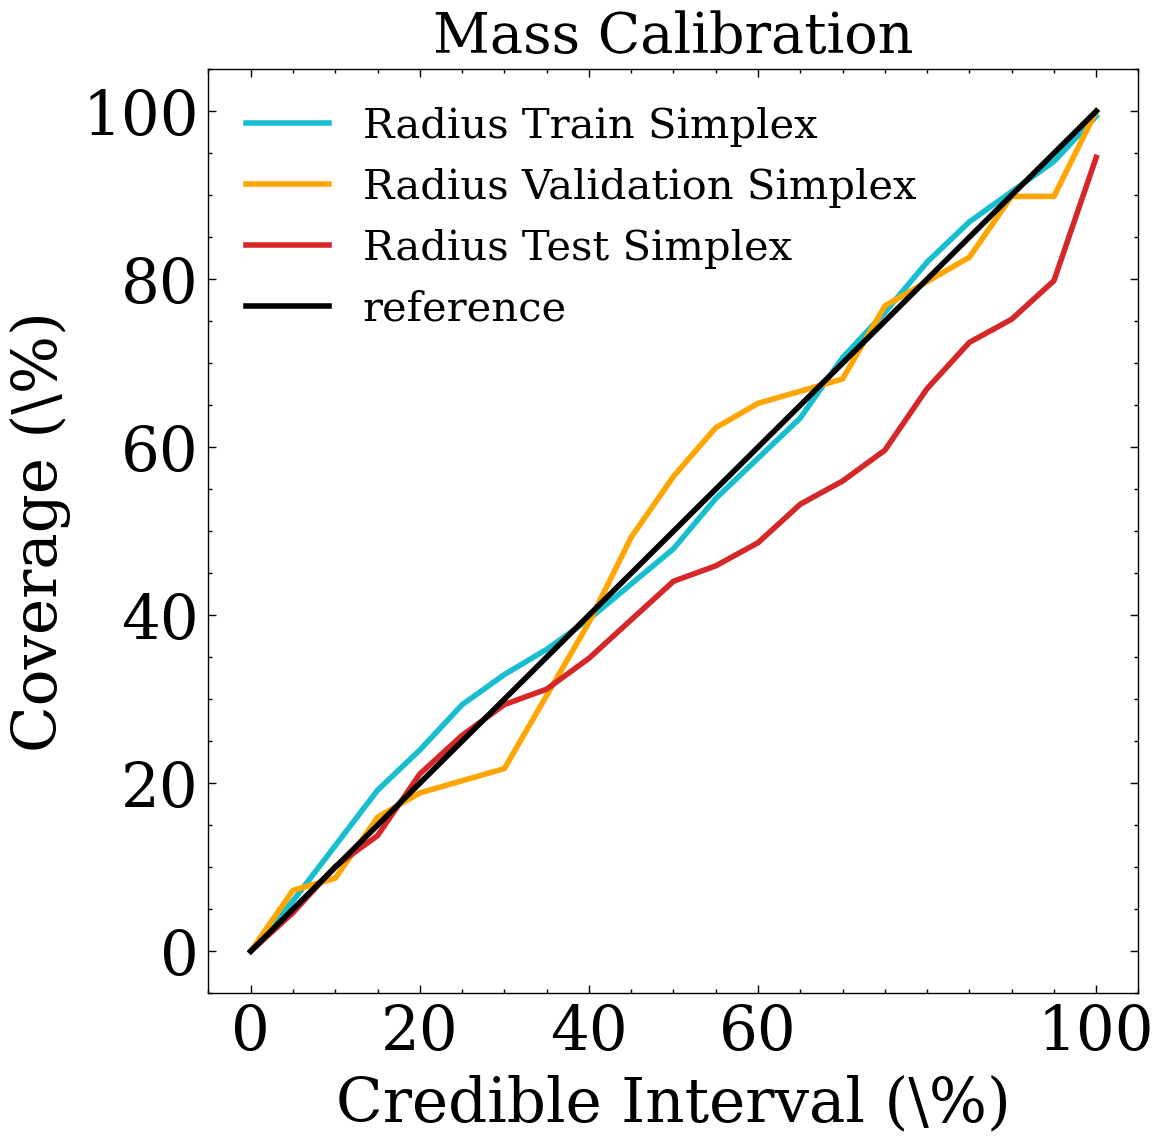

In [103]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_radius_train_simplex, label='Radius Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_radius_validation_simplex, label='Radius Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_radius_test_simplex, label='Radius Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Mass Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Radius ECP - Mass Analysis - 2PCs.png')
plt.show()

In [304]:
def PC_RMSE_calculator(components_kept, predictions_mean_list, models_output_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

    predictions_mean = predictions_mean_list[0]
    predictions_mean_train = predictions_mean_list[1]
    predictions_mean_validation = predictions_mean_list[2]
    predictions_mean_test = predictions_mean_list[3]

    models_output = models_output_list[0]
    models_output_train = models_output_list[1]
    models_output_validation = models_output_list[2]
    models_output_test = models_output_list[3]

    model_predictions = model_predictions_list[0]
    model_predictions_train = model_predictions_list[1]
    model_predictions_validation = model_predictions_list[2]
    model_predictions_test = model_predictions_list[3]

    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


    if centering_data:
        num_components=components_kept+1
    else:
        num_components=components_kept



    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
    models_PC_train["N"] = models_output_train["N"]
    models_PC_train["Z"] = models_output_train["Z"]
    models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################

    #########################################
    #Creating principal components that are for validation
    models_PC_validation = {}
    if centering_data:
        models_PC_validation[str("PC_0")] = predictions_mean_validation
    for i in range(components_kept):
        models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
    models_PC_validation["N"] = models_output_validation["N"]
    models_PC_validation["Z"] = models_output_validation["Z"]
    models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
    models_PC_validation = pd.DataFrame(models_PC_validation)
    #########################################

    #########################################
    #Creating principal components that are for testing
    models_PC_testing = {}
    if centering_data:
        models_PC_testing[str("PC_0")] = predictions_mean_test
    for i in range(components_kept):
        # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
        models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

    models_PC_testing["N"] = models_output_test["N"]
    models_PC_testing["Z"] = models_output_test["Z"]
    models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
    models_PC_testing = pd.DataFrame(models_PC_testing)
    #########################################

    #Creating principal components that are valid everywhere (testing + training + validation)
    models_PC = {}
    if centering_data:
        models_PC[str("PC_0")] = predictions_mean
    for i in range(components_kept):
        models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
    models_PC = pd.DataFrame(models_PC)
    models_PC["N"] = Full_set.T[0]
    models_PC["Z"] = Full_set.T[1]
    models_PC["A"] = models_PC["N"] + models_PC["Z"]
    #########################################

    key_list_PCs=list(models_PC_testing.keys())


    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_train["truth"].tolist())-predictions_mean_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    #Making the list of principal components across the validation part
    X_validation=[]
    for i in range(num_components):
        X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
    X_validation=np.array(X_validation)

    #Making the list of principal components across the testing part
    X_test=[]
    for i in range(num_components):
        X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
    X_test=np.array(X_test)
    #Making the list of principal components across the entire chart (training+validation+testing)
    X_full=[]
    for i in range(num_components):
        X_full.append(models_PC[key_list_PCs[i]].tolist())
    X_full=np.array(X_full)

    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
    #1.5) Construct the super model across the entire range and the test range
    if centering_data:
        beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
    else:
        beta_full=np.copy(beta)

    # supermodel=X.T.dot(beta_full)
    supermodel=X_train.T.dot(beta_full)
    supermodel_train=np.copy(supermodel)
    supermodel_validation=X_validation.T.dot(beta_full)
    supermodel_test=X_test.T.dot(beta_full)
    supermodel_full=X_full.T.dot(beta_full)

    
    super_model_resituals_train=supermodel_train-models_output_train['truth'].tolist()
    super_model_residuals_validation= supermodel_validation-models_output_validation['truth'].tolist()
    super_model_residuals_test = supermodel_test-models_output_test['truth'].tolist()
    super_model_residuals_full = supermodel_full-models_output['truth'].tolist()

    sigma_train=np.sqrt(np.sum(super_model_resituals_train**2) / len(super_model_resituals_train) )
    sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
    sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
    sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [305]:
predictions_mean_mass_list = [predictions_mean_mass, predictions_mean_mass_train, predictions_mean_mass_validation, predictions_mean_mass_test]
models_output_mass_list = models_output_mass_list
model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

In [306]:
if centering_data:
    s_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, predictions_mean_mass_list, models_output_mass_list, model_predictions_mass_list)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

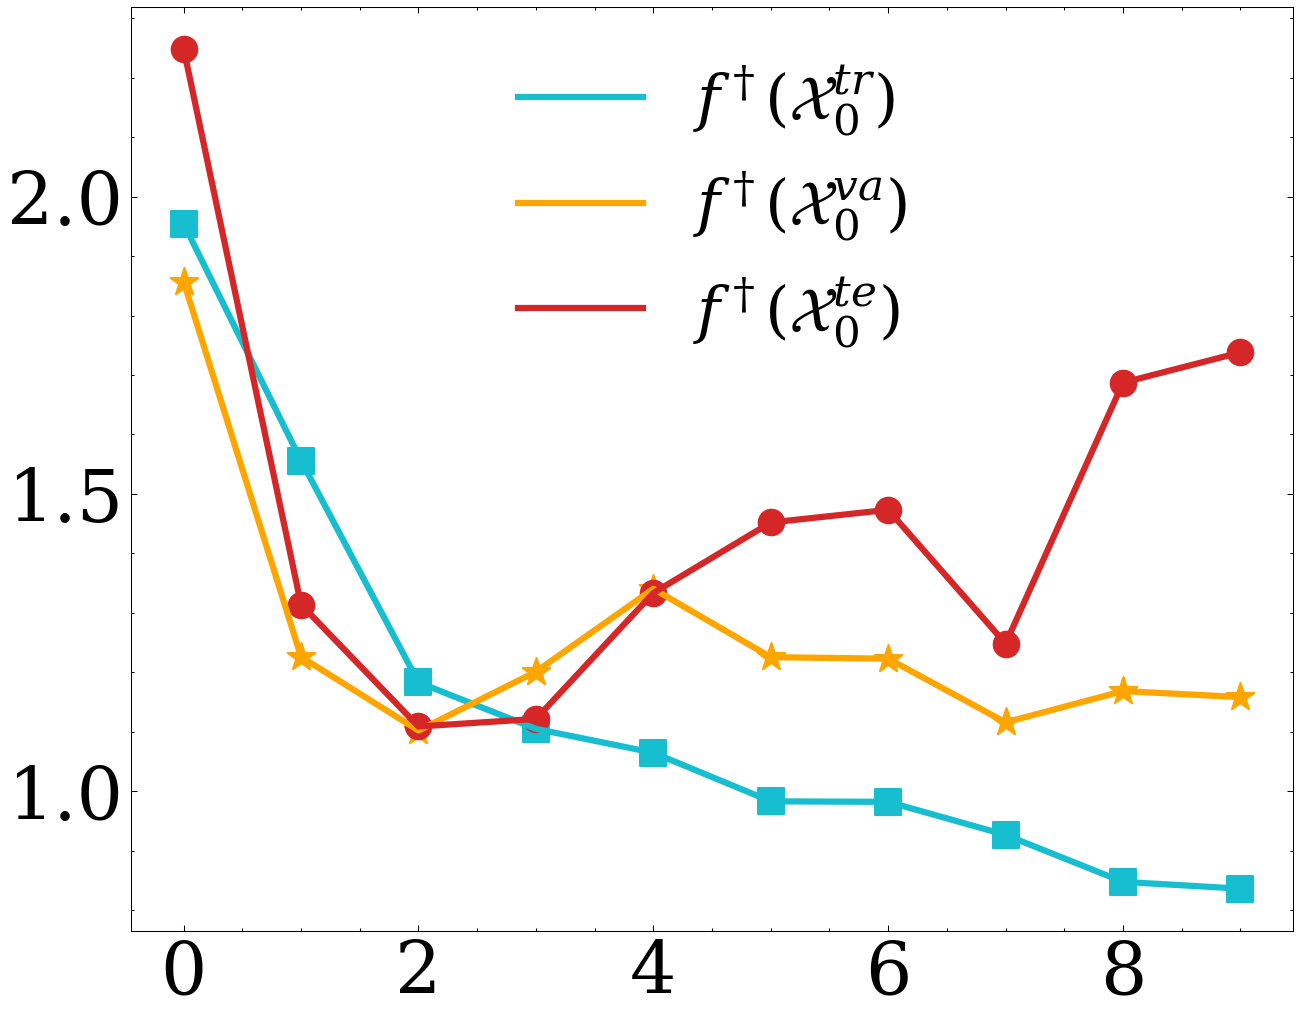

In [335]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_train)), s_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_train)), s_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_test)), s_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_test)), s_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
plt.legend(fontsize=30)
plt.savefig('Plots/Heterogeneous with Experimental Data/Mass RMSE decays as the number of PCs.png')
plt.show()